In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
csv_data = pd.read_csv("sales_data & retail_sales_data.csv" , encoding="cp1252" )

In [4]:
excel_data = pd.read_excel("sales_data.xlsx")

In [5]:
with open("sales_data.json" , "r")as json_file:
    json_data = json.load(json_file)
json_df =pd.DataFrame(json_data)

In [6]:
print("File Loaded Successfully!")

File Loaded Successfully!


In [11]:
print(csv_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [12]:
excel_data.info()
json_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [10]:
csv_data.head(3)
excel_data.head(3)
json_df.head(3)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,,NYC,NY,10022,USA,NA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,,Reims,,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,,Paris,,75508,France,EMEA,Da Cunha,Daniel,Medium


In [17]:
csv_data.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [20]:
csv_data["ADDRESSLINE2"] = csv_data["ADDRESSLINE2"].fillna("Not Available")
csv_data["STATE"] = csv_data["STATE"].fillna("Not Specified")
csv_data["TERRITORY"] = csv_data["TERRITORY"].fillna("Unknown")
csv_data["POSTALCODE"] = csv_data["POSTALCODE"].fillna("00000")

In [21]:
csv_data.isnull().sum()

ORDERNUMBER         0
QUANTITYORDERED     0
PRICEEACH           0
ORDERLINENUMBER     0
SALES               0
ORDERDATE           0
STATUS              0
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
PRODUCTLINE         0
MSRP                0
PRODUCTCODE         0
CUSTOMERNAME        0
PHONE               0
ADDRESSLINE1        0
ADDRESSLINE2        0
CITY                0
STATE               0
POSTALCODE          0
COUNTRY             0
TERRITORY           0
CONTACTLASTNAME     0
CONTACTFIRSTNAME    0
DEALSIZE            0
dtype: int64

In [22]:
csv_data.fillna({
    "ADDRESSLINE2": "Not Available",
    "STATE": "Not Specified",
    "TERRITORY": "Unknown",
    "POSTALCODE": "00000"
}, inplace=True)

In [23]:
csv_data.isnull().sum()

ORDERNUMBER         0
QUANTITYORDERED     0
PRICEEACH           0
ORDERLINENUMBER     0
SALES               0
ORDERDATE           0
STATUS              0
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
PRODUCTLINE         0
MSRP                0
PRODUCTCODE         0
CUSTOMERNAME        0
PHONE               0
ADDRESSLINE1        0
ADDRESSLINE2        0
CITY                0
STATE               0
POSTALCODE          0
COUNTRY             0
TERRITORY           0
CONTACTLASTNAME     0
CONTACTFIRSTNAME    0
DEALSIZE            0
dtype: int64

In [24]:
csv_data.dropna(thresh=10, inplace=True)

In [25]:
# Remove duplicates
csv_data.drop_duplicates(inplace=True)

In [28]:
unified_data = pd.concat([csv_data, excel_data, json_df], ignore_index=True)

In [29]:
unified_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       8469 non-null   int64  
 1   QUANTITYORDERED   8469 non-null   int64  
 2   PRICEEACH         8469 non-null   float64
 3   ORDERLINENUMBER   8469 non-null   int64  
 4   SALES             8469 non-null   float64
 5   ORDERDATE         8469 non-null   object 
 6   STATUS            8469 non-null   object 
 7   QTR_ID            8469 non-null   int64  
 8   MONTH_ID          8469 non-null   int64  
 9   YEAR_ID           8469 non-null   int64  
 10  PRODUCTLINE       8469 non-null   object 
 11  MSRP              8469 non-null   int64  
 12  PRODUCTCODE       8469 non-null   object 
 13  CUSTOMERNAME      8469 non-null   object 
 14  PHONE             8469 non-null   object 
 15  ADDRESSLINE1      8469 non-null   object 
 16  ADDRESSLINE2      5948 non-null   object 


In [30]:
print(unified_data.head())

   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1   ADDRESSLINE2           CITY          STATE  \
0        897 Long Airport Avenue  Not Available            NYC             NY   
1             59 rue de l'

In [31]:
unified_data.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [32]:
unified_data["ADDRESSLINE2"] = unified_data["ADDRESSLINE2"].fillna("Not Available")
unified_data["STATE"] = unified_data["STATE"].fillna("Not Specified")
unified_data["TERRITORY"] = unified_data["TERRITORY"].fillna("Unknown")
unified_data["POSTALCODE"] = unified_data["POSTALCODE"].fillna("00000")

In [33]:
unified_data.dropna(thresh=10, inplace=True)

In [34]:
unified_data.drop_duplicates(inplace=True)

In [42]:
if "ORDERDATE" in unified_data.columns:
    unified_data["ORDERDATE"] = pd.to_datetime(unified_data["ORDERDATE"], errors="coerce")

# Derive new columns
if "QUANTITYORDERED" in unified_data.columns and "PRICEEACH" in unified_data.columns:
    unified_data["Total_Sales"] = unified_data["QUANTITYORDERED"] * unified_data["PRICEEACH"]

# Extract Month and Year if ORDERDATE exists
if "ORDERDATE" in unified_data.columns:
    unified_data["Month"] = unified_data["ORDERDATE"].dt.month
    unified_data["Year"] = unified_data["ORDERDATE"].dt.year

In [43]:
unified_data.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,MSRP,Total_Sales,Month,Year
count,7876.000000,7876.000000,7876.000000,7876.000000,7876.000000,7876,7876.000000,7876.000000,7876.000000,7876.000000,7876.000000,7876.000000,7876.000000
mean,10258.502666,35.153885,83.630973,6.453403,3562.555086,2004-05-10 20:39:36.841036160,2.714195,7.081767,2003.815515,100.772473,2941.018441,7.081767,2003.815515
min,10100.000000,6.000000,26.880000,1.000000,482.130000,2003-01-06 00:00:00,1.000000,1.000000,2003.000000,33.000000,482.130000,1.000000,2003.000000
25%,10178.000000,27.000000,68.710000,3.000000,2204.600000,2003-11-07 00:00:00,2.000000,4.000000,2003.000000,68.000000,2100.000000,4.000000,2003.000000
50%,10262.000000,35.000000,95.800000,6.000000,3185.710000,2004-06-15 00:00:00,3.000000,8.000000,2004.000000,99.000000,2800.000000,8.000000,2004.000000
75%,10333.000000,43.000000,100.000000,9.000000,4514.920000,2004-11-17 00:00:00,4.000000,11.000000,2004.000000,124.000000,3756.000000,11.000000,2004.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,2005-05-31 00:00:00,4.000000,12.000000,2005.000000,214.000000,9048.160000,12.000000,2005.000000
std,92.267563,9.765696,20.248462,4.225154,1850.215098,NaN,1.203680,3.657518,0.701105,40.303667,1109.493612,3.657518,0.701105


In [44]:
# Calculate total sales and average sales
total_sales = unified_data["Total_Sales"].sum()
avg_order_value = unified_data["Total_Sales"].mean()


In [45]:
print("\n---- Key Numbers ----")
print(f"Total Sales for All Data: {total_sales:,.2f}")
print(f"Average Sale Value: {avg_order_value:,.2f}\n")



---- Key Numbers ----
Total Sales for All Data: 23,163,461.24
Average Sale Value: 2,941.02



In [46]:
# Group data by 'PRODUCTLINE' and sum their sales
category_sales = unified_data.groupby("PRODUCTLINE")["Total_Sales"].sum().sort_values(ascending=False)


In [47]:
print("---- Sales by Product Category ----")
print(category_sales)
print("\n")


---- Sales by Product Category ----
PRODUCTLINE
Classic Cars        8347993.70
Vintage Cars        4567643.80
Motorcycles         2723319.32
Trucks and Buses    2675343.00
Planes              2412208.99
Ships               1855082.58
Trains               581869.85
Name: Total_Sales, dtype: float64




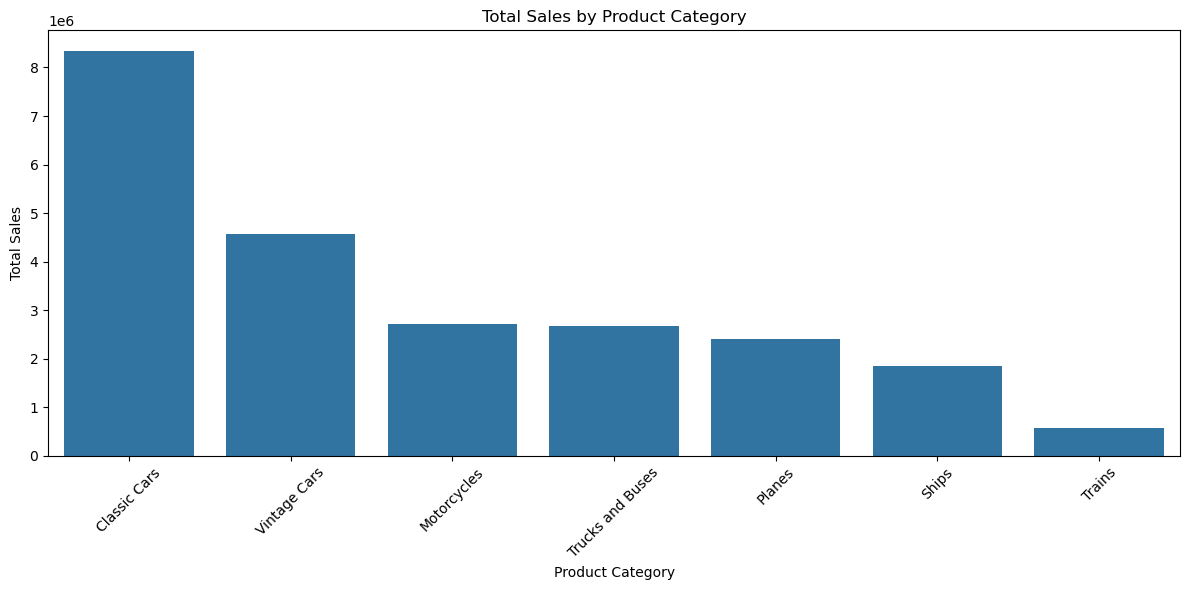

In [48]:
# --- Bar Plot ---
# Shows sales for each product category
plt.figure(figsize=(12, 6))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45) # Rotate the labels on the x-axis
plt.tight_layout()      # Fixes layout problems
plt.show() # Show the chart


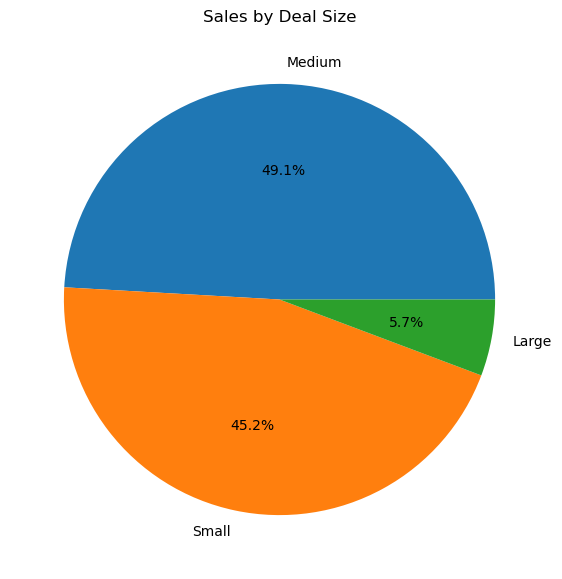

In [49]:
# --- Pie Chart ---
# Shows how much of sales comes from 'Small', 'Medium', or 'Large' deals
if "DEALSIZE" in unified_data.columns:
    dealsize_counts = unified_data["DEALSIZE"].value_counts()
    
    plt.figure(figsize=(7, 7))
    plt.pie(dealsize_counts.values, labels=dealsize_counts.index, autopct="%1.1f%%")
    plt.title("Sales by Deal Size")
    plt.show()

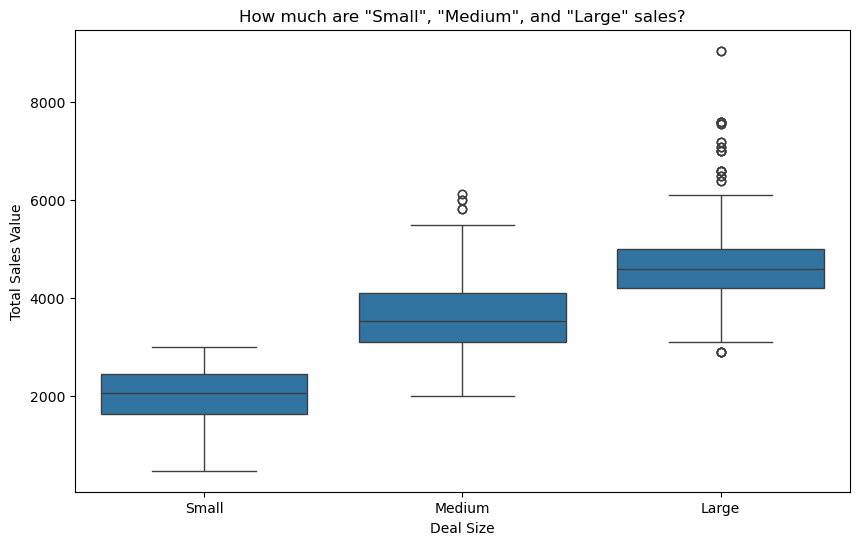

In [50]:
# --- Box Plot ---
# This was required by your problem statement.
# It shows the range of sales for each deal size.
if "DEALSIZE" in unified_data.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='DEALSIZE', y='Total_Sales', data=unified_data)
    plt.title('How much are "Small", "Medium", and "Large" sales?')
    plt.xlabel('Deal Size')
    plt.ylabel('Total Sales Value')
    plt.show()


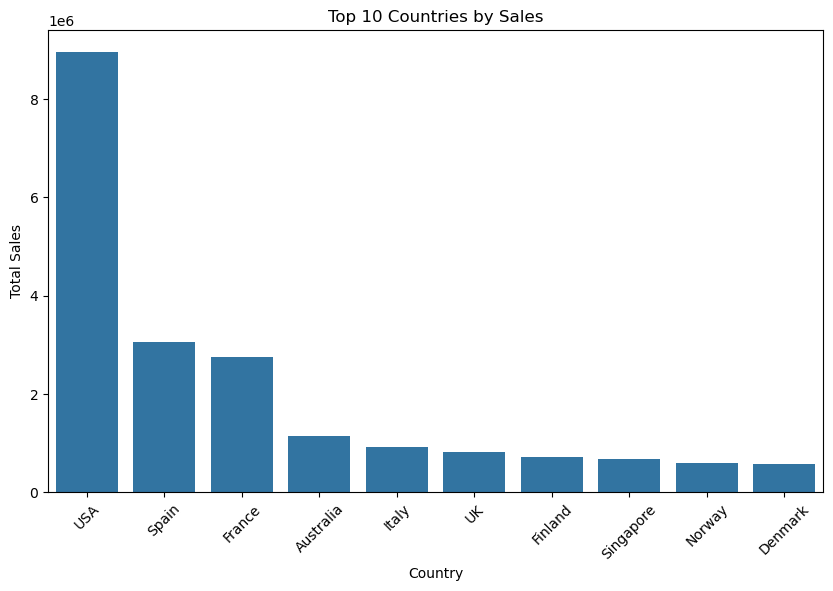

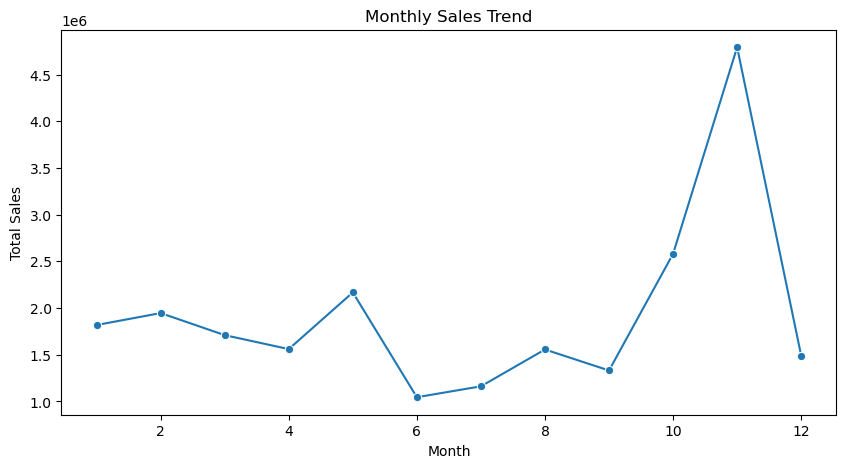

In [52]:
# Region / Country-wise Sales Distribution
if "COUNTRY" in unified_data.columns:
    country_sales = unified_data.groupby("COUNTRY")["Total_Sales"].sum().sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=country_sales.index[:10], y=country_sales.values[:10])
    plt.title("Top 10 Countries by Sales")
    plt.xlabel("Country")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.show()

# Monthly Sales Trend
if "Month" in unified_data.columns:
    monthly_sales = unified_data.groupby("Month")["Total_Sales"].sum()
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Total Sales")
    plt.show()
